In [61]:
#import necessary libraries
import numpy as np # contains mathematical tools 
import matplotlib.pyplot as plt # for plotting charts
import pandas as pd #for importing and managing datasets
import os  # interraction with OS, for displaying the current working dire
import pyreadstat as py
import sklearn
# Define base path safely 
base_path = Path.cwd()  # current working directory of the notebook

# Construct paths to your CSVs inside data folder
values_path = base_path / "data" / "train_values.csv"
labels_path = base_path / "data" / "train_labels.csv"

# Load CSVs
train_values = pd.read_csv(values_path)
train_labels = pd.read_csv(labels_path)

# Merge on 'id'
df = train_values.merge(train_labels, on='id')
print("Dataset shape:", df.shape)


Dataset shape: (59400, 41)


In [31]:
#check if both data are merged correctly
len(df) == len(train_label) == len(train_values)

True

In [5]:
df.isnull().sum()

id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

In [6]:
df['status_group'].value_counts()

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

In [7]:
# look for duplicates
df[df['id'].duplicated()]

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group


In [32]:
missing = pd.DataFrame(df.isnull().sum()).reset_index()
missing.columns = ['column', 'number of missing values']
missing[missing['number of missing values']>0]

,column,number of missing values
3,funder,3637
5,installer,3655
8,wpt_name,2
11,subvillage,371
18,public_meeting,3334
20,scheme_management,3878
21,scheme_name,28810
22,permit,3056


In [62]:
# drop unnecessary or irrelevant fields
# unneeded columns (fields that won't help predict the target label)
unneeded_col = ['id', 'recorded_by', 'wpt_name', 'funder', 'installer', 'num_private']
df = df.drop(unneeded_col, axis=1)

       amount_tsh date_recorded           funder  gps_height     installer  \
0          6000.0    2011-03-14            Roman        1390         Roman   
1             0.0    2013-03-06          Grumeti        1399       GRUMETI   
2            25.0    2013-02-25     Lottery Club         686  World vision   
3             0.0    2013-01-28           Unicef         263        UNICEF   
4             0.0    2011-07-13      Action In A           0       Artisan   
...           ...           ...              ...         ...           ...   
59395        10.0    2013-05-03  Germany Republi        1210           CES   
59396      4700.0    2011-05-07      Cefa-njombe        1212          Cefa   
59397         0.0    2011-04-11              NaN           0           NaN   
59398         0.0    2011-03-08            Malec           0          Musa   
59399         0.0    2011-03-23       World Bank         191         World   

       longitude   latitude  num_private                    bas

In [63]:
# get all categorical variables
df['region_code'] = df['region_code'].astype('object')
df['district_code'] = df['district_code'].astype('object')

# get categorical variables
cat_var = [col for col in df.columns if df[col].dtypes == 'object']
col_count = {}

# find number of unique values in each categorical variable
for col in cat_var:
    count = df[col].nunique()
    col_count[col] = count
col_count_df = pd.DataFrame(col_count.items())
col_count_df.columns = ['Field', 'Number of Unique Values']
col_count_df.head()

,Field,Number of Unique Values
0,date_recorded,356
1,basin,9
2,subvillage,19287
3,region,21
4,region_code,27


In [64]:
# remove redundant data (fields with information provided in other columns) repeating values
redundant_col = ['subvillage','latitude', 'longitude', 'region_code', 'district_code', 'lga', 'ward', 'scheme_name', 'extraction_type', 'extraction_type_group', 'payment', 'water_quality', 'quantity', 'source', 'source_type', 'waterpoint_type', 'management']
df = df.drop(redundant_col, axis=1)

In [65]:
#handle date values for easier data filling
# derive age of water pump (i.e., years since construction)
df['construction_year'] = pd.to_datetime(df['construction_year'])
df['date_recorded'] = pd.to_datetime(df['date_recorded'])
df['age'] = (df['date_recorded'] - df['construction_year']) / np.timedelta64(1, 'Y')

# delete construction_year and date_recorded columns 
df = df.drop(['construction_year', 'date_recorded'], axis=1)

In [66]:
df.columns# columns that are left after others being dropped

Index(['amount_tsh', 'gps_height', 'basin', 'region', 'population',
       'public_meeting', 'scheme_management', 'permit',
       'extraction_type_class', 'management_group', 'payment_type',
       'quality_group', 'quantity_group', 'source_class',
       'waterpoint_type_group', 'status_group', 'age'],
      dtype='object')

In [67]:
#this identifies he columns that are inputs and outputs
X = df.drop("status_group", axis=1)  
Y = df["status_group"]

In [25]:
print(X)

[[6000.0 1390 'Lake Nyasa' ... 'groundwater' 'communal standpipe'
  41.22465753424651]
 [0.0 1399 'Lake Victoria' ... 'surface' 'communal standpipe'
  43.20547945205473]
 [25.0 686 'Pangani' ... 'surface' 'communal standpipe' 43.18082191780815]
 ...
 [0.0 0 'Rufiji' ... 'groundwater' 'hand pump' 41.3013698630137]
 [0.0 0 'Rufiji' ... 'groundwater' 'hand pump' 41.20821917808219]
 [0.0 191 'Wami / Ruvu' ... 'groundwater' 'hand pump' 41.24931506849308]]


In [39]:
df.isnull().sum()

amount_tsh                  0
gps_height                  0
basin                       0
region                      0
population                  0
public_meeting           3334
scheme_management        3878
permit                   3056
extraction_type_class       0
management_group            0
payment_type                0
quality_group               0
quantity_group              0
source_class                0
waterpoint_type_group       0
status_group                0
age                         0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib
from pathlib import Path

# ---------------- Base paths ----------------
base_path = Path.cwd()  # current working directory
models_path = base_path / "models"
models_path.mkdir(exist_ok=True)  # create folder 


for col in ['scheme_management', 'public_meeting', 'permit']:
    X[col] = X[col].fillna(X[col].mode()[0])

# encoding categorical values
cat_cols = X.select_dtypes(include='object').columns
encoders_X = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders_X[col] = le

# encoding target
le_Y = LabelEncoder()
Y = le_Y.fit_transform(Y)


# feature column so as to match with the model and the app
feature_columns = X.columns.tolist()


In [69]:
print(X[:5])# check if the data is fully encoded


   amount_tsh  gps_height  basin  region  population  public_meeting  \
0      6000.0        1390      1       3         109            True   
1         0.0        1399      4       9         280            True   
2        25.0         686      5       8         250            True   
3         0.0         263      7      12          58            True   
4         0.0           0      4       4           0            True   

   scheme_management  permit  extraction_type_class  management_group  \
0                  6   False                      0                 4   
1                  1    True                      0                 4   
2                  6    True                      0                 4   
3                  6    True                      5                 4   
4                  6    True                      0                 1   

   payment_type  quality_group  quantity_group  source_class  \
0             0              2               1             0   


In [70]:
# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)


In [71]:
from sklearn.tree import DecisionTreeClassifier
#Decision Tree Classifier is the appropriate model to use because the target variable is categorical.
# Now train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, Y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Accuracy: 0.75
Confusion Matrix:
[[5242  320  882]
 [ 423  297  147]
 [1073  162 3334]]


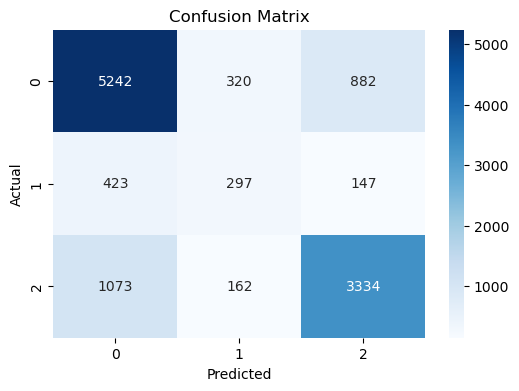

              precision    recall  f1-score   support

           0       0.78      0.81      0.80      6444
           1       0.38      0.34      0.36       867
           2       0.76      0.73      0.75      4569

    accuracy                           0.75     11880
   macro avg       0.64      0.63      0.63     11880
weighted avg       0.74      0.75      0.74     11880



In [21]:
# model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
Y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {acc:.2f}")

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(Y_test, Y_pred))


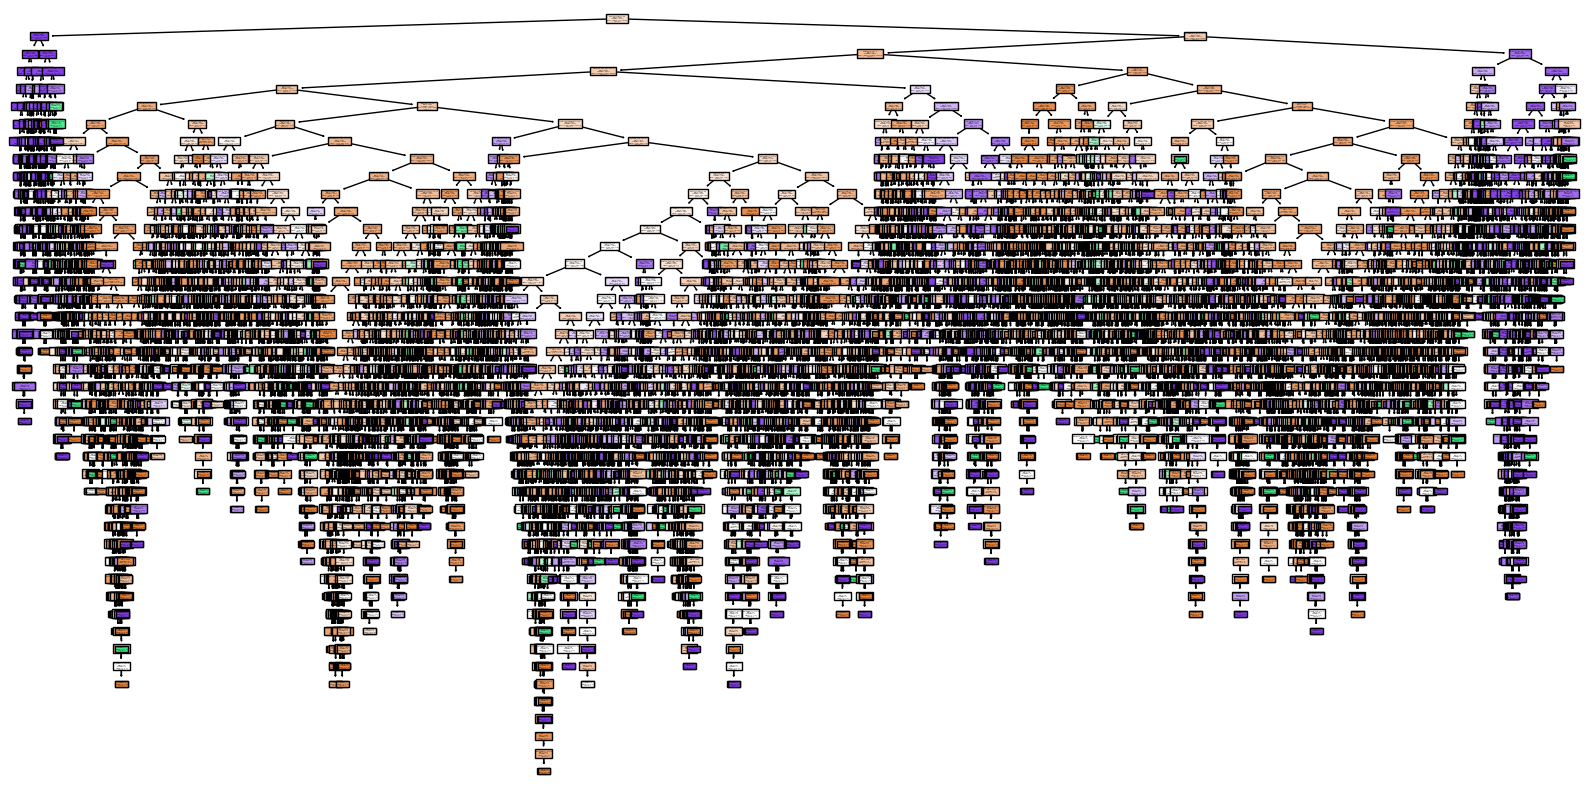

In [22]:
# visualization of the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X_train.columns, class_names=[str(c) for c in model.classes_])
plt.show()


In [72]:

joblib.dump(model, models_path / "pump_model.pkl")
joblib.dump(encoders_X, models_path / "encoders_X.pkl")
joblib.dump(le_Y, models_path / "le_Y.pkl")
joblib.dump(feature_columns, models_path / "feature_columns.pkl")


['C:\\ASS ML\\models\\feature_columns.pkl']

In [73]:
print(encoders_X.keys()) # check if all encoders are included

dict_keys(['basin', 'region', 'scheme_management', 'extraction_type_class', 'management_group', 'payment_type', 'quality_group', 'quantity_group', 'source_class', 'waterpoint_type_group'])
